# 12 — LSTM/GRU: ฝึกและเทียบผลกับ XGBoost และ Open-Meteo

ผลมาจาก `python -m src.lstm --dev` แล้วตามด้วย `--test` (ปี 2025 รันครั้งเดียว) notebook นี้อ่านเฉพาะผลที่บันทึกไว้

**กฎ (ประกาศในวัน 11–12 ก่อนฝึก):**
- **Early stopping:** ใช้ window ที่ target อยู่ใน **พ.ย.–ธ.ค. 2023** ไม่ใช้ dev 2024
- **LSTM หรือ GRU:** เลือกด้วย validation loss ช่วงเดียวกัน (ค่าเฉลี่ย 3 seeds)
- **ตัดสินบน dev 2024 ด้วยค่าเฉลี่ย 3 seeds:** ชนะ B1 ถ้า MAE < B1 − 0.02 **และ** recall ≥ สูงมาก ≥ B1 − 0.03 ถ้าไม่ผ่านให้ใช้ XGBoost ในแอป และไม่ปรับ RNN ต่อ
- **Test 2025 ครั้งเดียว** ใช้รายงานเท่านั้น

⚠️ covariate ในข้อมูลย้อนหลังเป็นค่าวิเคราะห์ของ Open-Meteo (พยากรณ์สมบูรณ์) ทั้ง RNN และ XGBoost ได้ input ชุดเดียวกัน

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

In [2]:
import json

from src.lstm import METRICS_PATH, SEEDS, TEST_RESULTS_PATH

docs = ROOT / "docs"
m = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
b1 = m["baseline_b1"]
base = pd.read_csv(docs / "lstm_baseline_dev_2024.csv")
base_lead = pd.read_csv(docs / "lstm_baseline_by_lead_dev_2024.csv", index_col=0)
dev = pd.read_csv(docs / "lstm_dev_2024.csv")
lead = pd.read_csv(docs / "lstm_by_lead_dev_2024.csv", index_col=0)
cell = m["selected_cell"]
print("validation loss (Nov-Dec 2023) per seed:", {c: [round(v, 5) for v in vs] for c, vs in m["val_losses"].items()})
print("selected:", cell.upper())
print("decision:", m["decision"])

validation loss (Nov-Dec 2023) per seed: {'lstm': [0.00413, 0.0043, 0.00435], 'gru': [0.00445, 0.00522, 0.00465]}
selected: LSTM
decision: {'rnn_wins': False, 'reason': 'MAE 0.4628 vs B1 0.4503 - 0.02 -> fail; >=Very high recall 0.873 vs B1 0.831 - 0.03 -> ok', 'app_model': 'XGBoost'}


## 1. Learning curves (validation = พ.ย.–ธ.ค. 2023)

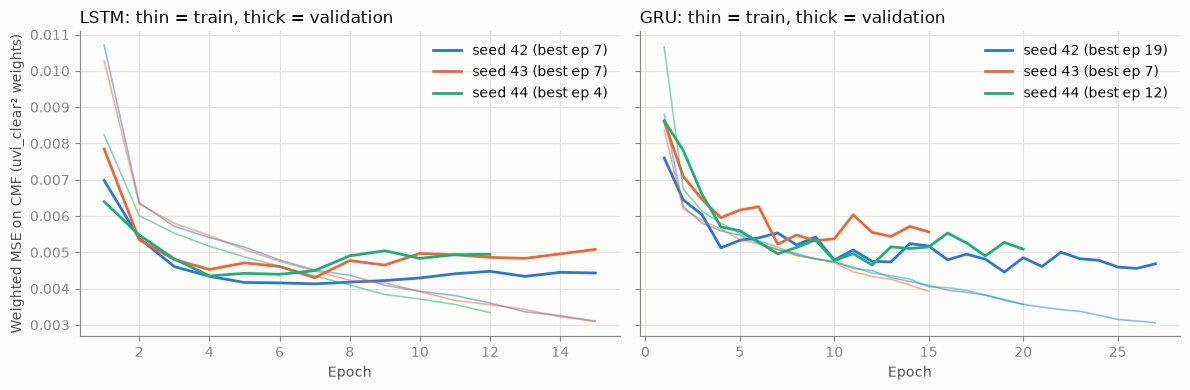

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = {42: C_OM, 43: C_NASA, 44: C_THIRD}
for ax, c in zip(axes, ("lstm", "gru")):
    for s in SEEDS:
        h = m["histories"][c][str(s)]
        ep = np.arange(1, len(h["val_loss"]) + 1)
        ax.plot(ep, h["loss"], color=colors[s], lw=1.2, alpha=0.5)
        ax.plot(ep, h["val_loss"], color=colors[s], lw=2, label=f"seed {s} (best ep {h['best_epoch']})")
    ax.set_title(f"{c.upper()}: thin = train, thick = validation", loc="left")
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Weighted MSE on CMF (uvi_clear² weights)")
fig.tight_layout()
save(fig, "lstm_learning_curves.png")

## 2. ผลบน dev 2024 (ค่าเฉลี่ย ± SD ของ 3 seeds)

In [4]:
summ = pd.DataFrame({"mean": m["dev_2024"]["mean"], "sd": m["dev_2024"]["sd"]}).T
display(dev.round(4))
display(summ.round(4))
comp = pd.DataFrame(
    {
        "model": [f"{cell.upper()} (mean of 3 seeds)", "B1 XGBoost + Open-Meteo", "B2 Open-Meteo uv_index"],
        "uvi_mae": [m["dev_2024"]["mean"]["uvi_mae"], base.loc[0, "uvi_mae"], base.loc[1, "uvi_mae"]],
        "uvi_mae_sd": [m["dev_2024"]["sd"]["uvi_mae"], 0.0, 0.0],
        "vh_recall": [m["dev_2024"]["mean"]["vh_recall"], base.loc[0, "vh_recall"], base.loc[1, "vh_recall"]],
        "vh_precision": [m["dev_2024"]["mean"]["vh_precision"], base.loc[0, "vh_precision"], base.loc[1, "vh_precision"]],
    }
)
comp.round(4)

,seed,model,uvi_mae,uvi_rmse,uvi_r2,uvi_bias,vh_recall,vh_precision,extreme_recall
0,42,lstm,0.4704,0.7296,0.9408,0.1976,0.8865,0.7435,0.2264
1,43,lstm,0.4625,0.7088,0.9441,0.1584,0.8723,0.7639,0.2272
2,44,lstm,0.4555,0.7051,0.9447,0.1480,0.8594,0.7625,0.2186


,uvi_mae,uvi_rmse,uvi_r2,uvi_bias,vh_recall,vh_precision,extreme_recall
mean,0.4628,0.7145,0.9432,0.1680,0.8727,0.7566,0.2241
sd,0.0075,0.0132,0.0021,0.0261,0.0135,0.0114,0.0048


,model,uvi_mae,uvi_mae_sd,vh_recall,vh_precision
0,LSTM (mean of 3 seeds),0.4628,0.0075,0.8727,0.7566
1,B1 XGBoost + Open-Meteo,0.4503,0.0000,0.8312,0.7931
2,B2 Open-Meteo uv_index,1.1624,0.0000,0.6169,0.7535


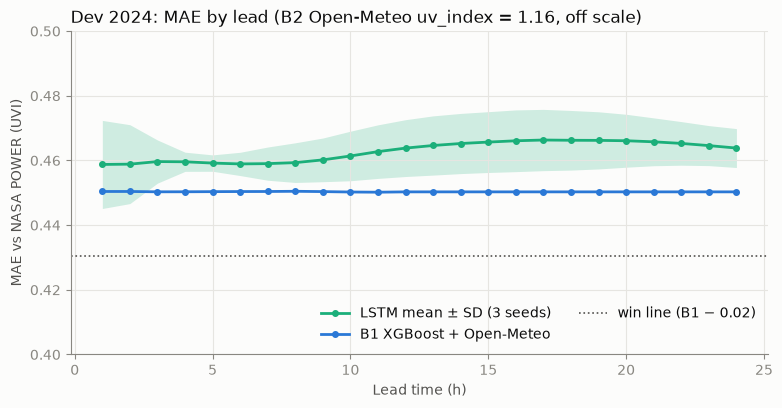

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
rnn = lead.to_numpy()
mu, sd = rnn.mean(axis=1), rnn.std(axis=1, ddof=1)
ax.fill_between(lead.index, mu - sd, mu + sd, color=C_THIRD, alpha=0.2, lw=0)
ax.plot(lead.index, mu, color=C_THIRD, marker="o", ms=4, label=f"{cell.upper()} mean ± SD (3 seeds)")
ax.plot(base_lead.index, base_lead["B1"], color=C_OM, marker="o", ms=4, label="B1 XGBoost + Open-Meteo")
ax.axhline(b1["uvi_mae"] - 0.02, color=INK2, ls=":", lw=1.2, label="win line (B1 − 0.02)")
ax.set_xlabel("Lead time (h)")
ax.set_ylabel("MAE vs NASA POWER (UVI)")
ax.set_ylim(0.40, 0.50)
ax.set_title(f"Dev 2024: MAE by lead (B2 Open-Meteo uv_index = {base_lead['B2'].mean():.2f}, off scale)", loc="left")
ax.legend(loc="lower right", ncol=2)
save(fig, "lstm_dev_by_lead.png")

## 3. Test 2025 (ครั้งเดียว, ใช้รายงานเท่านั้น)

In [6]:
if TEST_RESULTS_PATH.exists():
    t = json.loads(TEST_RESULTS_PATH.read_text(encoding="utf-8"))
    rows = [{"model": f"{t['cell'].upper()} seed {r['seed']}", **{k: v for k, v in r.items() if k not in ("by_lead", "seed", "model")}} for r in t["rnn_runs"]]
    rows.append({"model": f"{t['cell'].upper()} mean", **t["mean"]})
    rows.append({"model": f"{t['cell'].upper()} SD", **t["sd"]})
    for key in ("xgboost_final", "openmeteo"):
        rows.append({"model": t[key]["model"], **{k: v for k, v in t[key].items() if k not in ("by_lead", "model")}})
    display(pd.DataFrame(rows).round(4))
    display(pd.DataFrame(t["criteria"]))
else:
    print("2025 test not run yet")

,model,uvi_mae,uvi_rmse,uvi_r2,uvi_bias,vh_recall,vh_precision,extreme_recall
0,LSTM seed 42,0.5001,0.7661,0.9316,0.0844,0.8027,0.7316,0.0815
1,LSTM seed 43,0.4927,0.7421,0.9358,0.1083,0.8283,0.7528,0.0652
2,LSTM seed 44,0.4981,0.7578,0.9331,0.1343,0.8366,0.7363,0.0435
3,LSTM mean,0.4970,0.7553,0.9335,0.1090,0.8225,0.7402,0.0634
4,LSTM SD,0.0038,0.0122,0.0021,0.0250,0.0177,0.0112,0.0191
5,XGBoost final,0.4801,0.7524,0.9340,0.1065,0.8166,0.7445,0.2174
6,Open-Meteo uv_index,1.1640,1.6354,0.6882,-0.0780,0.5666,0.7283,0.0000


,id,desc,value,passed,threshold
0,L1,RNN mean MAE < 1.0,0.496953,True,NaN
1,L2,RNN mean MAE < XGBoost final MAE - 0.02,0.496953,False,0.460121


## สรุป

**LSTM ไม่ผ่านเกณฑ์ที่ประกาศไว้ → ใช้ XGBoost ในแอป (รวมพยากรณ์ 6–24 ชม.) และไม่ปรับ RNN ต่อ**

- **เลือกสถาปัตยกรรม (validation พ.ย.–ธ.ค. 2023):** LSTM ได้ loss 0.00413 / 0.00430 / 0.00435 ส่วน GRU ได้ 0.00445 / 0.00522 / 0.00465 จึงเลือก **LSTM** early stopping หยุดที่ epoch 7 / 7 / 4
- **dev 2024 (3 seeds):**

  | | LSTM mean ± SD | B1 XGBoost + Open-Meteo | เกณฑ์ | ผล |
  |---|---|---|---|---|
  | MAE (UVI) | **0.463 ± 0.008** | 0.450 | < 0.430 | ❌ |
  | recall ≥ สูงมาก | **0.873** | 0.831 | ≥ 0.801 | ✅ |

  LSTM แย่กว่า B1 ทุก seed (0.470 / 0.463 / 0.455) และมี bias บวก (+0.15 ถึง +0.20) ซึ่งเป็นเหตุผลที่ recall สูงกว่า B1 (ทำนายสูงไว้ก่อน) ส่วน MAE แทบคงที่ทุก lead เหมือน baseline เพราะ covariate เป็นพยากรณ์สมบูรณ์ ประวัติ 48 ชม. จึงไม่ได้เพิ่มข้อมูลที่ features ของชั่วโมงเป้าหมายไม่มี
- **Test 2025 (ครั้งเดียว, ใช้รายงานเท่านั้น):**
  - LSTM refit บน 2023–2024 ได้ MAE **0.497 ± 0.004** ส่วน XGBoost final บน window ชุดเดียวกันได้ 0.480 และ Open-Meteo 1.164
  - **L1 ผ่าน** (< 1.0) **L2 ไม่ผ่าน** (ต้องต่ำกว่า 0.460)
  - recall ≥ สูงมาก 0.823 ± 0.018 (XGBoost 0.817) และ recall รุนแรงมาก 0.06 (XGBoost 0.22)
  - ตอน refit early stopping หยุดที่ epoch 5 / 1 / 1 คือ validation พ.ย.–ธ.ค. 2024 ดีที่สุดตั้งแต่ epoch แรก ๆ แปลว่าการฝึกต่อไม่ช่วยในช่วงนั้น รายงานไว้ตามจริงโดยไม่ได้แก้
- **ข้อจำกัด:** input อนาคตเป็นค่าวิเคราะห์ ไม่ใช่พยากรณ์ที่ออกล่วงหน้าจริง ผลจริงตามระยะพยากรณ์ของทั้ง LSTM และ XGBoost จะแย่กว่านี้